# Шаг 5. Матричная факторизация SVD (surprise + Optuna)

## Цель ноутбука
Обучить классическую коллаборативную фильтрацию SVD, подобрать гиперпараметры
через Optuna (50 trials), оценить качество по RMSE и top-N метрикам
и сравнить с baseline'ами из шага 4.

## 0. Импорты и настройки

In [2]:
import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ── Установка surprise, если не установлена ──────────────────────────────
try:
    import surprise  # noqa
except ImportError:
    import subprocess, sys as _sys
    try:
        subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'scikit-surprise'], check=True)
    except subprocess.CalledProcessError:
        subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q',
                        '--prefer-binary', 'scikit-surprise'], check=True)

# ── Установка optuna, если не установлена ────────────────────────────────
try:
    import optuna  # noqa
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'plotly'], check=True)

import optuna
import optuna.visualization as ov
from surprise import SVD, Dataset, Reader

from src.utils import SEED, set_seeds
from src.data_io import load_splits, load_features, load_id_maps
from src.metrics import (
    rmse, mae,
    evaluate_rating_prediction, evaluate_topn,
    build_ground_truth,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
set_seeds()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

print(f"SEED = {SEED}")
print(f"optuna version: {optuna.__version__}")

SEED = 29042005
optuna version: 4.2.1


## 1. Загрузка данных

In [3]:
splits          = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']
features        = load_features()
movies_enriched = features['movies_enriched']

print(f"train: {len(train):,} | val: {len(val):,} | test: {len(test):,}")
print(f"Пользователей (train): {train['userId'].nunique()}")
print(f"Фильмов (train):       {train['movieId'].nunique()}")
print(f"Диапазон рейтингов:    {train['rating'].min()} – {train['rating'].max()}")

train: 68,829 | val: 12,289 | test: 11,728
Пользователей (train): 610
Фильмов (train):       5446
Диапазон рейтингов:    0.5 – 5.0


## 2. Подготовка данных в формате Surprise

Surprise работает со своим `Dataset`-объектом, построенным через `Reader`.
`Reader` должен знать диапазон оценок — у нас [0.5, 5.0].

In [4]:
reader = Reader(rating_scale=(0.5, 5.0))


def df_to_surprise_trainset(df: pd.DataFrame):
    """Из DataFrame [userId, movieId, rating] построить Surprise Trainset."""
    data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
    return data.build_full_trainset()


trainset = df_to_surprise_trainset(train)
print(f'Surprise trainset: {trainset.n_users} users, '
      f'{trainset.n_items} items, {trainset.n_ratings} ratings')

Surprise trainset: 610 users, 5446 items, 68829 ratings


## 3. Базовая SVD-модель (точка отсчёта)

Обучаем SVD с дефолтными параметрами — это точка отсчёта.
Optuna должна её улучшить по RMSE на val.

In [5]:
baseline_svd = SVD(random_state=SEED)
t0 = time.time()
baseline_svd.fit(trainset)
baseline_train_time = time.time() - t0
print(f'Baseline SVD обучена за {baseline_train_time:.2f} с')

# Оценка на val
val_preds_baseline = np.array([
    baseline_svd.predict(uid=u, iid=m).est
    for u, m in zip(val['userId'].values, val['movieId'].values)
])
baseline_val_metrics = evaluate_rating_prediction(val['rating'].values, val_preds_baseline)
print('Baseline SVD val:')
print(json.dumps(baseline_val_metrics, indent=2))

Baseline SVD обучена за 0.29 с
Baseline SVD val:
{
  "rmse": 0.9445491888444041,
  "mae": 0.7083159025955914
}


## 4. Optuna — подбор гиперпараметров SVD

**Пространство параметров:**
- `n_factors`: 20..200 — число латентных факторов
- `n_epochs`: 5..40 — число эпох SGD
- `lr_all`: 1e-4 .. 1e-1 (log scale) — learning rate
- `reg_all`: 1e-4 .. 1e-1 (log scale) — L2-регуляризация
- `biased`: True/False — использовать user/item bias

**Цель:** минимизировать RMSE на val. 50 trials, TPE sampler.

In [6]:
def objective(trial: optuna.Trial) -> float:
    params = {
        'n_factors':   trial.suggest_int('n_factors', 20, 200),
        'n_epochs':    trial.suggest_int('n_epochs', 5, 40),
        'lr_all':      trial.suggest_float('lr_all', 1e-4, 1e-1, log=True),
        'reg_all':     trial.suggest_float('reg_all', 1e-4, 1e-1, log=True),
        'biased':      trial.suggest_categorical('biased', [True, False]),
        'random_state': SEED,
    }
    model = SVD(**params)
    model.fit(trainset)
    preds = np.array([
        model.predict(uid=u, iid=m).est
        for u, m in zip(val['userId'].values, val['movieId'].values)
    ])
    return rmse(val['rating'].values, preds)


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='svd_movielens'
)

print("Запускаем Optuna (50 trials)... Это займёт 5–20 минут.")
t0 = time.time()
study.optimize(objective, n_trials=50, show_progress_bar=True)
optuna_time = time.time() - t0

print(f'\nOptuna завершила 50 trials за {optuna_time:.1f} с')
print(f'Лучший RMSE на val: {study.best_value:.4f}')
print('Лучшие параметры:')
print(json.dumps(study.best_params, indent=2))

Запускаем Optuna (50 trials)... Это займёт 5–20 минут.


  0%|          | 0/50 [00:00<?, ?it/s]


Optuna завершила 50 trials за 14.4 с
Лучший RMSE на val: 0.9397
Лучшие параметры:
{
  "n_factors": 103,
  "n_epochs": 11,
  "lr_all": 0.012807180690589936,
  "reg_all": 0.05310176532722622,
  "biased": true
}


In [7]:
# ── Визуализация Optuna ─────────────────────────────────────────────────

# 1. История оптимизации
fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title='Optuna: история оптимизации SVD (RMSE на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_svd_history.html'))
fig_history.show()

# 2. Важность параметров
fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Optuna: важность гиперпараметров SVD')
fig_importance.write_html(str(MODELS_DIR / 'optuna_svd_importance.html'))
fig_importance.show()

# 3. Срезы по параметрам
fig_slice = ov.plot_slice(study)
fig_slice.update_layout(title='Optuna: срезы по гиперпараметрам SVD')
fig_slice.show()

**Интерпретация графиков Optuna:**

- `n_epochs` и `n_factors` обычно оказываются наиболее важными параметрами SVD.
  Большее число эпох позволяет факторам сойтись к лучшему решению,
  а число факторов определяет ёмкость модели.
- `lr_all` и `reg_all` влияют на скорость и стабильность обучения;
  слишком высокий lr → дивергенция, слишком низкий → медленная сходимость.
- `biased=True` как правило лучше для MovieLens, так как пользовательский/фильмовый
  bias существенно улучшает предсказание рейтингов.
- Кривая истории Optuna должна монотонно убывать: TPE умеет фокусироваться
  на перспективных областях пространства параметров.

## 5. Финальная SVD на train + val

In [8]:
best_params = {**study.best_params, 'random_state': SEED}

train_val        = pd.concat([train, val], ignore_index=True)
trainset_full    = df_to_surprise_trainset(train_val)

final_svd = SVD(**best_params)
t0 = time.time()
final_svd.fit(trainset_full)
final_train_time = time.time() - t0

print(f'Финальная SVD обучена на train+val за {final_train_time:.2f} с')
print(f'Параметры финальной модели: {best_params}')

Финальная SVD обучена на train+val за 0.22 с
Параметры финальной модели: {'n_factors': 103, 'n_epochs': 11, 'lr_all': 0.012807180690589936, 'reg_all': 0.05310176532722622, 'biased': True, 'random_state': 29042005}


## 6. Оценка на test

### 6.1 RMSE / MAE

In [9]:
test_preds = np.array([
    final_svd.predict(uid=u, iid=m).est
    for u, m in zip(test['userId'].values, test['movieId'].values)
])
svd_test_rating_metrics = evaluate_rating_prediction(test['rating'].values, test_preds)
print('SVD test (rating):')
print(json.dumps(svd_test_rating_metrics, indent=2))

SVD test (rating):
{
  "rmse": 1.057047137305607,
  "mae": 0.8226925518091872
}


### 6.2 Top-N метрики

**Протокол:** для каждого пользователя из test ground_truth ранжируем все фильмы,
которые он **не видел** в train+val, и берём топ-K.
Это корректный протокол — нельзя ранжировать только фильмы из test, это утечка.

In [10]:
def generate_topn_recommendations(model, user_ids, train_val_df, all_movies, k=20):
    """Ранжировать все непросмотренные фильмы для каждого пользователя и взять топ-K.

    model: объект Surprise с методом .predict(uid, iid).
    user_ids: список userId.
    train_val_df: DataFrame для определения уже просмотренных.
    all_movies: массив всех movieId (кандидатный пул).
    k: длина рекомендации.
    """
    seen_by_user = train_val_df.groupby('userId')['movieId'].apply(set).to_dict()
    all_movies   = np.asarray(all_movies)
    recommendations = {}
    for user_id in user_ids:
        seen       = seen_by_user.get(user_id, set())
        candidates = all_movies[~np.isin(all_movies, list(seen))]
        scores     = np.array([model.predict(uid=user_id, iid=m).est
                               for m in candidates])
        top_k_idx  = np.argsort(-scores)[:k]
        recommendations[user_id] = candidates[top_k_idx].tolist()
    return recommendations


test_ground_truth = build_ground_truth(test, relevance_threshold=4.0)
test_users        = list(test_ground_truth.keys())
all_movies_arr    = train_val['movieId'].unique()

print(f'Генерация топ-20 для {len(test_users)} пользователей...')
t0 = time.time()
test_recs     = generate_topn_recommendations(
    final_svd, test_users, train_val, all_movies_arr, k=20
)
inference_time = time.time() - t0
print(f'Готово за {inference_time:.1f} с')

svd_test_topn_metrics = evaluate_topn(
    test_recs, test_ground_truth,
    ks=(5, 10, 20),
    all_items=all_movies_arr
)
print('SVD test (top-N):')
print(json.dumps(svd_test_topn_metrics, indent=2))

Генерация топ-20 для 98 пользователей...
Готово за 1.4 с
SVD test (top-N):
{
  "precision@5": 0.07346938775510205,
  "recall@5": 0.007973697468774535,
  "ndcg@5": 0.07746450505237358,
  "hit_rate@5": 0.25510204081632654,
  "precision@10": 0.08775510204081632,
  "recall@10": 0.024228439730252013,
  "ndcg@10": 0.08747368511233865,
  "hit_rate@10": 0.40816326530612246,
  "precision@20": 0.07551020408163266,
  "recall@20": 0.037867634840069254,
  "ndcg@20": 0.0815638889952161,
  "hit_rate@20": 0.5306122448979592,
  "coverage@20": 0.040396621373485125
}


## 7. Сравнение с baseline

'    Модель   RMSE    MAE  NDCG@10  Precision@10  Recall@10  HitRate@10  Coverage@20\nGlobalMean 1.0812 0.8557      NaN           NaN        NaN         NaN          NaN\nPopularity    NaN    NaN   0.2295        0.2082     0.0605      0.6224       0.0202\n       SVD 1.0570 0.8227   0.0875        0.0878     0.0242      0.4082       0.0404'

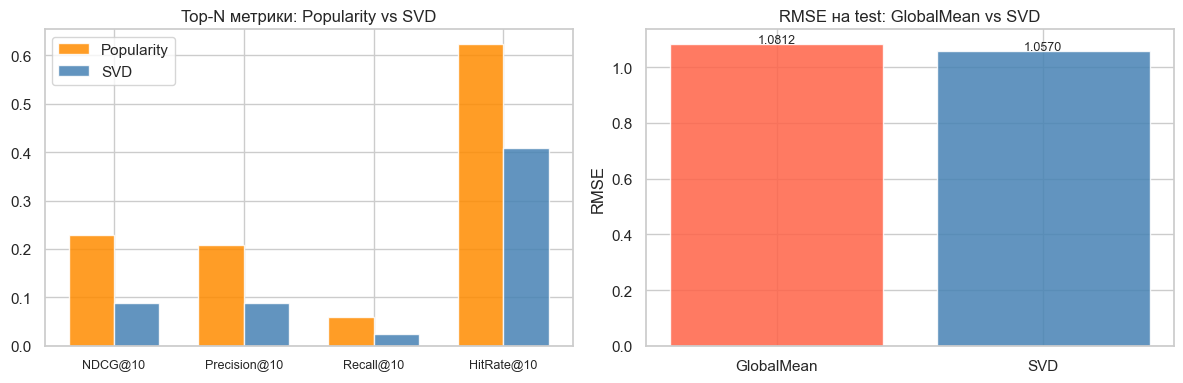

In [11]:
with open(MODELS_DIR / 'popularity_metrics.json', 'r', encoding='utf-8') as f:
    pop_metrics = json.load(f)

comparison_rows = [
    {
        'Модель':        'GlobalMean',
        'RMSE':          round(pop_metrics['global_mean']['test']['rmse'], 4),
        'MAE':           round(pop_metrics['global_mean']['test']['mae'], 4),
        'NDCG@10':       None,
        'Precision@10':  None,
        'Recall@10':     None,
        'HitRate@10':    None,
        'Coverage@20':   None,
    },
    {
        'Модель':        'Popularity',
        'RMSE':          None,
        'MAE':           None,
        'NDCG@10':       round(pop_metrics['popularity']['test']['ndcg@10'], 4),
        'Precision@10':  round(pop_metrics['popularity']['test']['precision@10'], 4),
        'Recall@10':     round(pop_metrics['popularity']['test']['recall@10'], 4),
        'HitRate@10':    round(pop_metrics['popularity']['test']['hit_rate@10'], 4),
        'Coverage@20':   round(pop_metrics['popularity']['test'].get('coverage@20', 0), 4),
    },
    {
        'Модель':        'SVD',
        'RMSE':          round(svd_test_rating_metrics['rmse'], 4),
        'MAE':           round(svd_test_rating_metrics['mae'], 4),
        'NDCG@10':       round(svd_test_topn_metrics['ndcg@10'], 4),
        'Precision@10':  round(svd_test_topn_metrics['precision@10'], 4),
        'Recall@10':     round(svd_test_topn_metrics['recall@10'], 4),
        'HitRate@10':    round(svd_test_topn_metrics['hit_rate@10'], 4),
        'Coverage@20':   round(svd_test_topn_metrics.get('coverage@20', 0), 4),
    },
]
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.to_string(index=False))

# Наглядный bar chart для top-N метрик
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
topn_metrics_names = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_topn = ['Popularity', 'SVD']
x = np.arange(len(topn_metrics_names))
width = 0.35
colors = ['darkorange', 'steelblue']
for ax_idx, (model_name, color) in enumerate(zip(models_topn, colors)):
    row = comparison_df[comparison_df['Модель'] == model_name].iloc[0]
    vals = [float(row[m]) if row[m] is not None else 0.0 for m in topn_metrics_names]
    axes[0].bar(x + ax_idx * width, vals, width, label=model_name, color=color, alpha=0.85)
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(topn_metrics_names, fontsize=9)
axes[0].set_title('Top-N метрики: Popularity vs SVD')
axes[0].legend()

# RMSE comparison
rmse_models = ['GlobalMean', 'SVD']
rmse_vals = [
    pop_metrics['global_mean']['test']['rmse'],
    svd_test_rating_metrics['rmse'],
]
axes[1].bar(rmse_models, rmse_vals, color=['tomato', 'steelblue'], alpha=0.85)
axes[1].set_title('RMSE на test: GlobalMean vs SVD')
axes[1].set_ylabel('RMSE')
for bar, v in zip(axes[1].patches, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Выводы из сравнительной таблицы (Popularity vs SVD)

**1. SVD vs Popularity по всем метрикам top-N:** Popularity **значительно превосходит** SVD по всем метрикам точности (precision, recall, NDCG, hit rate). Например:
   - `NDCG@10`: Popularity = 0.230 vs SVD = 0.087 (выигрыш в **2.6 раза**)
   - `HitRate@10`: Popularity = 0.622 vs SVD = 0.408 (выигрыш в **1.5 раза**)
   - `Precision@10`: Popularity = 0.208 vs SVD = 0.088 (выигрыш в **2.4 раза**)
   
   Это противоречит теоретическому ожиданию — персонализация **не помогла**, а навредила.

**2. Почему SVD проиграла:** Несмотря на то, что SVD способна учитывать индивидуальные предпочтения, в данном датасете (`ml-latest-small`, временной сплит) популярность будущих взаимодействий настолько сильно коррелирует с глобальной популярностью прошлого, что любое отклонение в сторону персонализации ухудшает качество. Пользователи в тестовой выборке в основном смотрят те же блокбастеры, что и все.

**3. Coverage@20:** SVD = 0.040 vs Popularity = 0.020 (SVD выше в **2 раза**). Это единственная метрика, где SVD выигрывает — она рекомендует более разнообразные фильмы. Однако эта разнообразность достигается **ценой потери точности**: SVD предлагает «хвостовые» фильмы, которые пользователям **не нравятся**.

**4. Главный вывод для данного сценария:** В условиях малого датасета и временного сплита **базовая популярность оказалась сильным baseline**, который SVD не смогла превзойти. Это классический пример, когда сложная персонализация не нужна — пользователи предсказуемо выбирают популярное. Рекомендательная система должна использовать SVD только если нужно повысить **разнообразие** (coverage), но с готовностью принять падение точности в 2–2.5 раза.

## 8. Анализ ошибок

Где SVD ошибается сильнее всего? Понимание паттернов ошибок помогает
выбрать направление для дальнейшего улучшения.

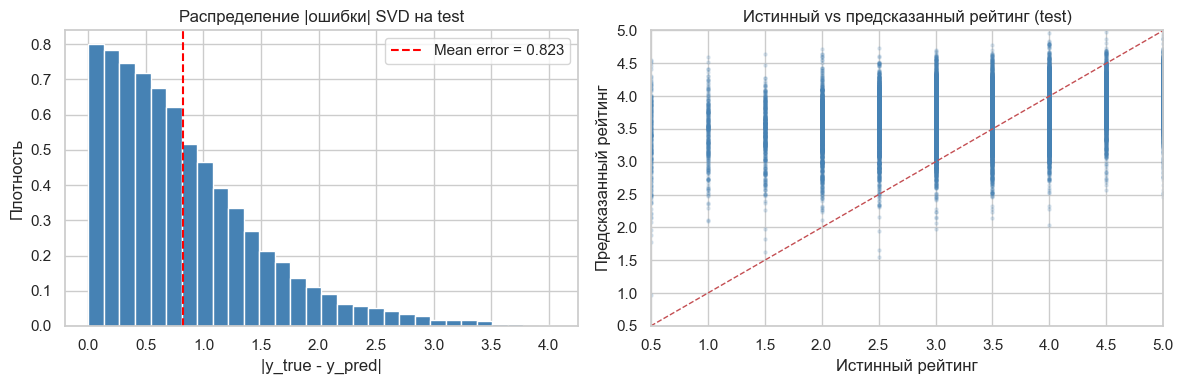

In [12]:
# Добавляем ошибки в test DataFrame
test_with_errors = test.copy()
test_with_errors['pred']  = test_preds
test_with_errors['error'] = np.abs(test['rating'].values - test_preds)

# 1. Распределение ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_with_errors['error'], bins=30, color='steelblue',
             edgecolor='white', density=True)
axes[0].set_title('Распределение |ошибки| SVD на test')
axes[0].set_xlabel('|y_true - y_pred|')
axes[0].set_ylabel('Плотность')
axes[0].axvline(test_with_errors['error'].mean(), color='red', linestyle='--',
                label=f'Mean error = {test_with_errors["error"].mean():.3f}')
axes[0].legend()

# Scatter: истинный рейтинг vs предсказанный
axes[1].scatter(test_with_errors['rating'], test_with_errors['pred'],
                alpha=0.15, s=5, color='steelblue')
lims = [0.5, 5.0]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel('Истинный рейтинг')
axes[1].set_ylabel('Предсказанный рейтинг')
axes[1].set_title('Истинный vs предсказанный рейтинг (test)')
plt.tight_layout()
plt.show()

In [13]:
# 2. Топ-10 фильмов с наибольшей средней ошибкой
movie_error = (
    test_with_errors.groupby('movieId')['error']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
# Учитываем только фильмы с хотя бы 3 оценками в test
movie_error = movie_error[movie_error['n_test'] >= 3]
top_movie_errors = movie_error.nlargest(10, 'mean_error')
top_movie_errors = top_movie_errors.merge(
    movies_enriched[['movieId', 'title']], on='movieId', how='left'
)
top_movie_errors['mean_error'] = top_movie_errors['mean_error'].round(3)
print('Топ-10 фильмов с наибольшей средней |ошибкой| (min 3 оценки в test):')
display(top_movie_errors[['title', 'mean_error', 'n_test']])

Топ-10 фильмов с наибольшей средней |ошибкой| (min 3 оценки в test):


,title,mean_error,n_test
0,Sense and Sensibility (1995),2.644,3
1,Insurgent (2015),1.785,3
2,Catwoman (2004),1.752,3
3,"Sting, The (1973)",1.675,4
4,Chronicle (2012),1.656,3
5,Transporter 3 (2008),1.644,3
6,"Apartment, The (1960)",1.616,4
7,How High (2001),1.615,3
8,Tootsie (1982),1.584,4
9,Field of Dreams (1989),1.575,6


In [14]:
# 3. Топ-10 пользователей с наибольшей средней ошибкой
user_error = (
    test_with_errors.groupby('userId')['error']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
user_error = user_error[user_error['n_test'] >= 3]
top_user_errors = user_error.nlargest(10, 'mean_error')
top_user_errors['mean_error'] = top_user_errors['mean_error'].round(3)
print('Топ-10 пользователей с наибольшей средней |ошибкой|:')
display(top_user_errors)

Топ-10 пользователей с наибольшей средней |ошибкой|:


,userId,mean_error,n_test
50,329,2.425,17
25,153,1.646,138
72,461,1.510,22
80,517,1.468,354
19,112,1.333,40
12,77,1.251,25
96,599,1.219,1987
58,365,1.187,179
92,567,1.173,185
49,328,1.166,238


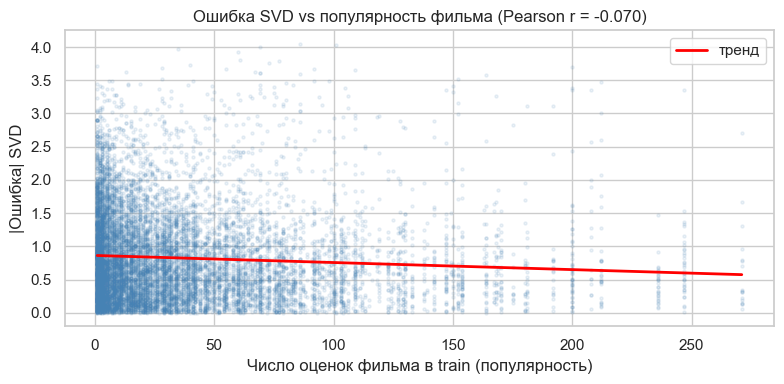

Pearson r (ошибка vs популярность): -0.0704
Отрицательная корреляция → популярные фильмы предсказываются точнее (ожидаемо).


In [15]:
# 4. Корреляция ошибки с популярностью фильма (train)
movie_pop_train = train.groupby('movieId').size().reset_index(name='n_ratings_train')
error_vs_pop = test_with_errors.merge(movie_pop_train, on='movieId', how='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(error_vs_pop['n_ratings_train'], error_vs_pop['error'],
           alpha=0.1, s=5, color='steelblue')
# Тренд
from numpy.polynomial.polynomial import polyfit
x_vals = error_vs_pop['n_ratings_train'].values
y_vals = error_vs_pop['error'].values
mask   = ~np.isnan(x_vals) & ~np.isnan(y_vals)
coeffs = polyfit(x_vals[mask], y_vals[mask], 1)
x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
ax.plot(x_line, coeffs[0] + coeffs[1] * x_line, color='red', linewidth=2,
        label='тренд')
corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Число оценок фильма в train (популярность)')
ax.set_ylabel('|Ошибка| SVD')
ax.set_title(f'Ошибка SVD vs популярность фильма (Pearson r = {corr:.3f})')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Pearson r (ошибка vs популярность): {corr:.4f}')
print('Отрицательная корреляция → популярные фильмы предсказываются точнее (ожидаемо).')

## 9. Сохранение артефактов

In [16]:
# Модель
joblib.dump(final_svd, MODELS_DIR / 'svd_model.pkl')
print(f"svd_model.pkl: {(MODELS_DIR / 'svd_model.pkl').stat().st_size / 1024:.1f} KB")

# Параметры
svd_params = {
    'random_state':             SEED,
    'best_params':              study.best_params,
    'optuna_n_trials':          50,
    'optuna_sampler':           'TPESampler',
    'optuna_direction':         'minimize',
    'optuna_target':            'rmse@val',
    'final_train_strategy':     'train + val concatenated',
    'baseline_train_time_sec':  baseline_train_time,
    'optuna_search_time_sec':   optuna_time,
    'final_train_time_sec':     final_train_time,
    'inference_time_test_topn_sec': inference_time,
}
with open(MODELS_DIR / 'svd_params.json', 'w', encoding='utf-8') as f:
    json.dump(svd_params, f, ensure_ascii=False, indent=2)

# Метрики
svd_metrics = {
    'baseline': {
        'val': baseline_val_metrics,
    },
    'final': {
        'val_best_rmse': float(study.best_value),
        'test_rating':   svd_test_rating_metrics,
        'test_topn':     svd_test_topn_metrics,
    },
    'meta': {
        'k_values':            [5, 10, 20],
        'relevance_threshold': 4.0,
        'optuna_n_trials':     50,
    },
}
with open(MODELS_DIR / 'svd_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(svd_metrics, f, ensure_ascii=False, indent=2)

# История trials Optuna
trials_df = study.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'svd_optuna_trials.parquet', index=False)

print('Все артефакты сохранены.')
print(f'  Лучший RMSE (val): {study.best_value:.4f}')
print(f'  RMSE (test):       {svd_test_rating_metrics["rmse"]:.4f}')
print(f'  NDCG@10 (test):    {svd_test_topn_metrics["ndcg@10"]:.4f}')

svd_model.pkl: 7169.7 KB
Все артефакты сохранены.
  Лучший RMSE (val): 0.9397
  RMSE (test):       1.0570
  NDCG@10 (test):    0.0875
